# Specific Stock Simulation


In [61]:
import matplotlib.pyplot as plt
import analysis_interfaces.interface_specific_stock as iss


## Block 1: Parameters


In [62]:
ticker = "TSLA"
initial_funds = 100
include_fundamentals = True
include_sentiment = False  # True requires API keys and adds latency

period = "10y"  # Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max

## Block 4: Simulate Daily Buy/Sell/Hold Strategy


In [63]:
df_pred = iss.build_prediction_and_stats(
            ticker,
            include_sentiment=include_sentiment,
            period=period,
        )

In [64]:
simulation_result = iss.simulate_prediction_signal_strategy(
    df_pred,
    initial_funds=initial_funds,
)


## Block 5: Portfolio Summary


In [65]:
simulation_result["price_history"]

,Date,Open,Close,Trade_Price
0,2016-03-16,14.533333,14.795333,14.664333
1,2016-03-17,14.764667,15.092000,14.928333
2,2016-03-18,15.273333,15.516000,15.394666
3,2016-03-21,15.689333,15.888000,15.788666
4,2016-03-22,15.814000,15.616000,15.715000
...,...,...,...,...
2509,2026-03-10,402.220001,399.239990,400.729996
2510,2026-03-11,402.279999,407.820007,405.050003
2511,2026-03-12,405.179993,395.010010,400.095001
2512,2026-03-13,399.170013,391.200012,395.185013


In [66]:
simulation_result["daily_history"]

,Date,Open,Close,Trade_Price,signal_text,signal_number,action,trade_units,trade_value,cash_balance,units_held,average_cost_per_unit,holdings_value,portfolio_value,profit_loss,profit_loss_pct
0,2016-03-16,14.533333,14.795333,14.664333,HOLD,0,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000
1,2016-03-17,14.764667,15.092000,14.928333,HOLD,0,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000
2,2016-03-18,15.273333,15.516000,15.394666,HOLD,0,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000
3,2016-03-21,15.689333,15.888000,15.788666,HOLD,0,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000
4,2016-03-22,15.814000,15.616000,15.715000,HOLD,0,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2509,2026-03-10,402.220001,399.239990,400.729996,HOLD,0,HOLD,0.000000,0.000000,0.000000,0.295784,448.839354,118.088713,118.088713,18.088713,18.088713
2510,2026-03-11,402.279999,407.820007,405.050003,HOLD,0,HOLD,0.000000,0.000000,0.000000,0.295784,448.839354,120.626543,120.626543,20.626543,20.626543
2511,2026-03-12,405.179993,395.010010,400.095001,STRONG SELL,-2,SELL,0.029578,11.834161,11.834161,0.266205,448.839354,105.153798,116.987959,16.987959,16.987959
2512,2026-03-13,399.170013,391.200012,395.185013,HOLD,0,HOLD,0.000000,0.000000,11.834161,0.266205,448.839354,104.139556,115.973718,15.973718,15.973718


In [67]:
simulation_result["transactions"]


,Date,action,signal_text,trade_price,units,trade_value,cash_balance,units_held,portfolio_value
0,2016-03-23,BUY,WEAK BUY,15.165000,0.329707,5.000000,95.000000,0.329707,99.892406
1,2016-03-31,BUY,STRONG BUY,15.303667,0.653438,10.000000,85.000000,0.983145,100.059811
2,2016-04-01,BUY,STRONG BUY,16.080667,0.621865,10.000000,75.000000,1.605010,100.422279
3,2016-04-04,BUY,STRONG BUY,16.537000,0.604705,10.000000,65.000000,2.209714,101.385152
4,2016-04-05,BUY,STRONG BUY,16.532333,0.604875,10.000000,55.000000,2.814589,102.936212
...,...,...,...,...,...,...,...,...,...
657,2026-01-07,BUY,WEAK BUY,433.654999,0.011530,5.000000,13.141482,0.265796,127.808663
658,2026-01-08,BUY,WEAK BUY,431.845001,0.011578,5.000000,8.141482,0.277375,129.021296
659,2026-01-09,BUY,WEAK BUY,440.480011,0.011351,5.000000,3.141482,0.288726,131.627343
660,2026-01-12,BUY,WEAK BUY,445.095001,0.007058,3.141482,0.000000,0.295784,132.795083


In [68]:
simulation_result["summary"]


,start_date,end_date,initial_funds,ending_cash_balance,units_held,average_cost_per_unit,latest_close,holdings_value,total_portfolio_value,profit_loss,profit_loss_pct,buy_transactions,sell_transactions
0,2016-03-16,2026-03-16,100.0,11.834161,0.266205,448.839354,399.220001,106.274521,118.108682,18.108682,18.108682,387,275


## Block 6: Consolidated Chart


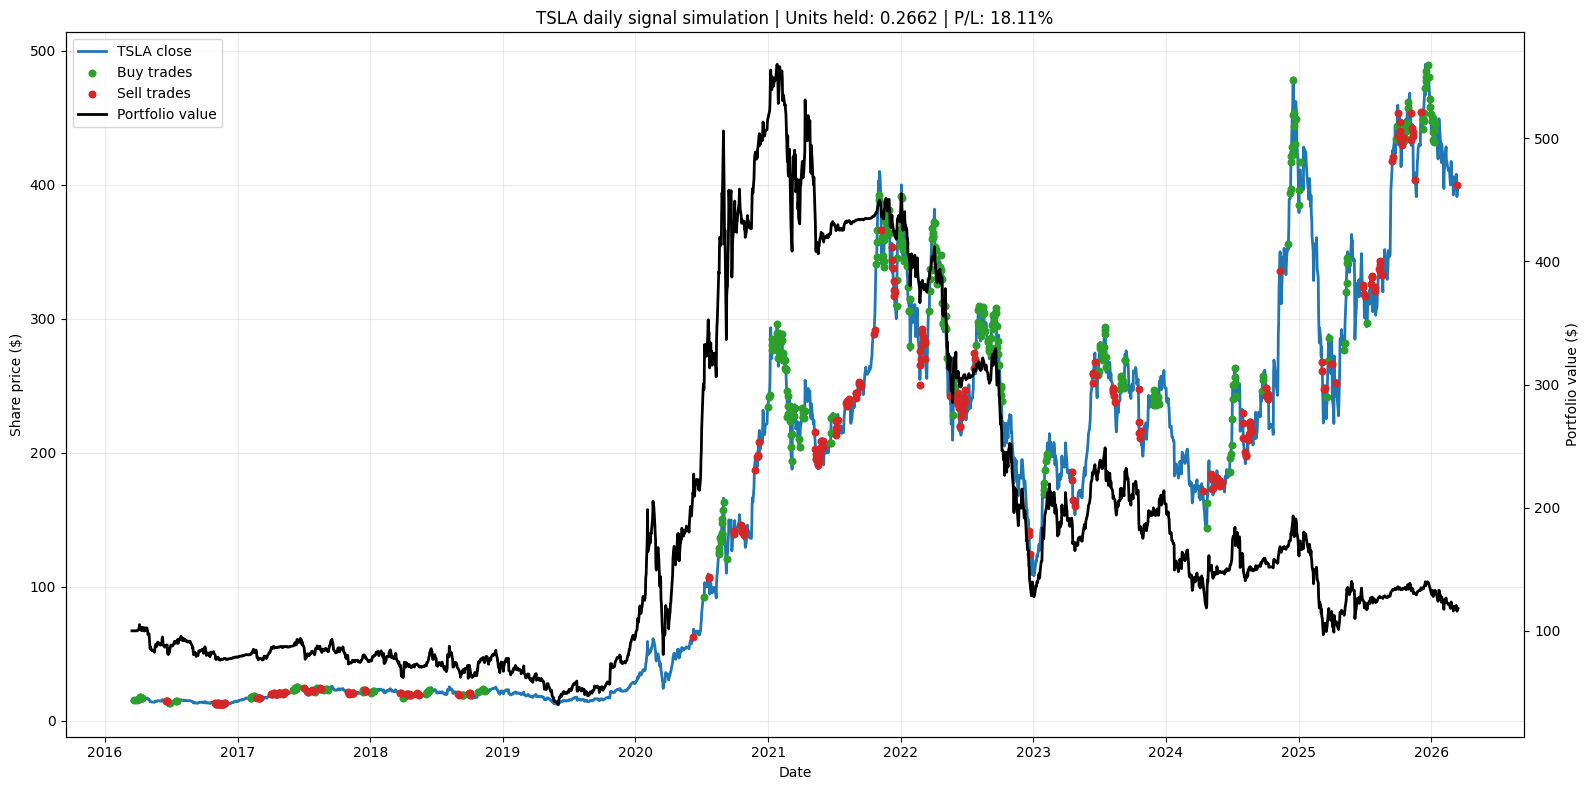

In [69]:
price_history = simulation_result["price_history"].copy()
daily_history = simulation_result["daily_history"].copy()
transactions = simulation_result["transactions"].copy()
simulation_summary = simulation_result["summary"].iloc[0]

buy_txns = transactions[transactions["action"] == "BUY"].copy()
sell_txns = transactions[transactions["action"] == "SELL"].copy()

fig, ax_price = plt.subplots(figsize=(16, 8))
ax_price.plot(
    price_history["Date"],
    price_history["Close"],
    color="#1f77b4",
    linewidth=2,
    label=f"{ticker} close",
)

if not buy_txns.empty:
    ax_price.scatter(
        buy_txns["Date"],
        buy_txns["trade_price"],
        color="#2ca02c",
        marker=".",
        s=90,
        label="Buy trades",
        zorder=5,
    )

if not sell_txns.empty:
    ax_price.scatter(
        sell_txns["Date"],
        sell_txns["trade_price"],
        color="#d62728",
        marker=".",
        s=90,
        label="Sell trades",
        zorder=5,
    )

ax_price.set_xlabel("Date")
ax_price.set_ylabel("Share price ($)")
ax_price.grid(alpha=0.25)

ax_portfolio = ax_price.twinx()
ax_portfolio.plot(
    daily_history["Date"],
    daily_history["portfolio_value"],
    color="#000000",
    linewidth=2,
    label="Portfolio value",
)
ax_portfolio.set_ylabel("Portfolio value ($)")

title = (
    f"{ticker} daily signal simulation | "
    f"Units held: {simulation_summary['units_held']:.4f} | "
    f"P/L: {simulation_summary['profit_loss_pct']:.2f}%"
)
ax_price.set_title(title)

handles_price, labels_price = ax_price.get_legend_handles_labels()
handles_portfolio, labels_portfolio = ax_portfolio.get_legend_handles_labels()
ax_price.legend(handles_price + handles_portfolio, labels_price + labels_portfolio, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Block 7: Daily Portfolio History


In [70]:
simulation_result["daily_history"][[
    "Date",
    "signal_text",
    "action",
    "trade_units",
    "trade_value",
    "cash_balance",
    "units_held",
    "holdings_value",
    "portfolio_value",
    "profit_loss_pct",
]]


,Date,signal_text,action,trade_units,trade_value,cash_balance,units_held,holdings_value,portfolio_value,profit_loss_pct
0,2016-03-16,HOLD,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000
1,2016-03-17,HOLD,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000
2,2016-03-18,HOLD,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000
3,2016-03-21,HOLD,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000
4,2016-03-22,HOLD,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
2509,2026-03-10,HOLD,HOLD,0.000000,0.000000,0.000000,0.295784,118.088713,118.088713,18.088713
2510,2026-03-11,HOLD,HOLD,0.000000,0.000000,0.000000,0.295784,120.626543,120.626543,20.626543
2511,2026-03-12,STRONG SELL,SELL,0.029578,11.834161,11.834161,0.266205,105.153798,116.987959,16.987959
2512,2026-03-13,HOLD,HOLD,0.000000,0.000000,11.834161,0.266205,104.139556,115.973718,15.973718
